**Author:** Biswajit Jana
**Date:** August 4, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-31-hot-jupiter-tidal-circularisation/notebook.ipynb)

**Learning goals** -- after this notebook you will be able to:
- Pull a live giant-planet sample from the NASA Exoplanet Archive and apply real quality cuts.
- Test the tidal-circularization prediction (short-period giant planets should have systematically lower eccentricity) using real eccentricity-vs-period data and a quantified threshold test.
- Report a real eccentric-fraction comparison between short- and long-period giant planets, with sample sizes at each step.

**Background.** Tidal forces raised by a star on a close-in planet damp orbital eccentricity over time, so short-period giant planets ("hot Jupiters") are expected to be more circular than longer-period giants, which have not had enough time (or a strong enough tidal force) to circularize.

# Hot-Jupiter eccentricity and tidal circularisation in the NASA Exoplanet Archive

**Archive:** exoplanet-archive  
**Date:** 2026-07-31  
**Scientific question:** Are short-period giant planets more circular than otherwise similar longer-period giants?

This notebook uses public observational data. It separates measurements from
interpretation, carries uncertainties through the main calculation, and records
the exact query or product identifier needed to reproduce the result.

## Analysis contract

A result is accepted only after these checks:

1. record the source, query, retrieval date, and selection cuts;
2. inspect missing values and quality flags before fitting;
3. report sample size and an uncertainty, not only a best value;
4. compare with a published result or accepted physical expectation;
5. state what the data cannot establish.

The saved CSV is the small, queried subset used here—not a replacement for the
upstream archive.

In [1]:
from pathlib import Path
import json
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use(["science", "no-latex"])
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8"}
RNG = np.random.default_rng(1999)

## Physical expectation

Tides dissipate orbital energy. Because tidal effects grow steeply at small
separation, close-in giant planets are expected to have lower eccentricities
than giants on wider orbits. We test that population-level expectation without
claiming to measure a tidal quality factor.

In [2]:
import requests

TAP = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
QUERY = '''
SELECT pl_name, hostname, disc_year, discoverymethod,
       pl_orbper, pl_orbeccen, pl_orbeccenerr1, pl_orbeccenerr2,
       pl_radj, pl_bmassj, st_mass, st_teff
FROM pscomppars
WHERE pl_orbper IS NOT NULL AND pl_orbeccen IS NOT NULL
AND pl_radj IS NOT NULL
'''
response = requests.get(TAP, params={"query": QUERY, "format": "csv"}, timeout=180)
response.raise_for_status()
all_planets = pd.read_csv(io.StringIO(response.text))
all_planets.to_csv("giant_planet_archive_query.csv", index=False)
giants = all_planets[
    all_planets.pl_radj.between(0.6, 2.2) &
    all_planets.pl_orbper.between(0.5, 100) &
    all_planets.pl_orbeccen.between(0, 0.95)
].copy()
giants.to_csv("giant_planet_sample.csv", index=False)
print(f"Retrieved {len(all_planets):,} planets with period, radius, and eccentricity")
print(f"Analysis sample: {len(giants):,} giant planets")

Retrieved 5,233 planets with period, radius, and eccentricity
Analysis sample: 944 giant planets


## Pre-registered comparison

We compare very hot giants ($P<5$ d) with giants at $10\le P<100$ d. The gap
between 5 and 10 days reduces boundary sensitivity. We report medians,
bootstrap the median difference, and use a two-sided Mann–Whitney test. Archive
eccentricities include measurements, fitted zeros, and sometimes fixed values;
that heterogeneity is a major caveat.

In [3]:
short = giants[giants.pl_orbper < 5].pl_orbeccen.to_numpy()
long = giants[giants.pl_orbper.between(10, 100, inclusive="left")].pl_orbeccen.to_numpy()
observed_delta = float(np.median(long) - np.median(short))
boot_delta = []
for _ in range(5000):
    a = RNG.choice(short, len(short), replace=True)
    b = RNG.choice(long, len(long), replace=True)
    boot_delta.append(np.median(b) - np.median(a))
delta_ci = np.percentile(boot_delta, [2.5, 97.5])
u = stats.mannwhitneyu(short, long, alternative="two-sided")
print(f"P < 5 d: n={len(short)}, median e={np.median(short):.3f}")
print(f"10 ≤ P < 100 d: n={len(long)}, median e={np.median(long):.3f}")
print(f"Median difference (long − short)={observed_delta:.3f}, "
      f"bootstrap 95% CI [{delta_ci[0]:.3f}, {delta_ci[1]:.3f}]")
print(f"Mann–Whitney U p={u.pvalue:.3g}")

P < 5 d: n=584, median e=0.000
10 ≤ P < 100 d: n=215, median e=0.120
Median difference (long − short)=0.120, bootstrap 95% CI [0.088, 0.149]
Mann–Whitney U p=2.8e-32


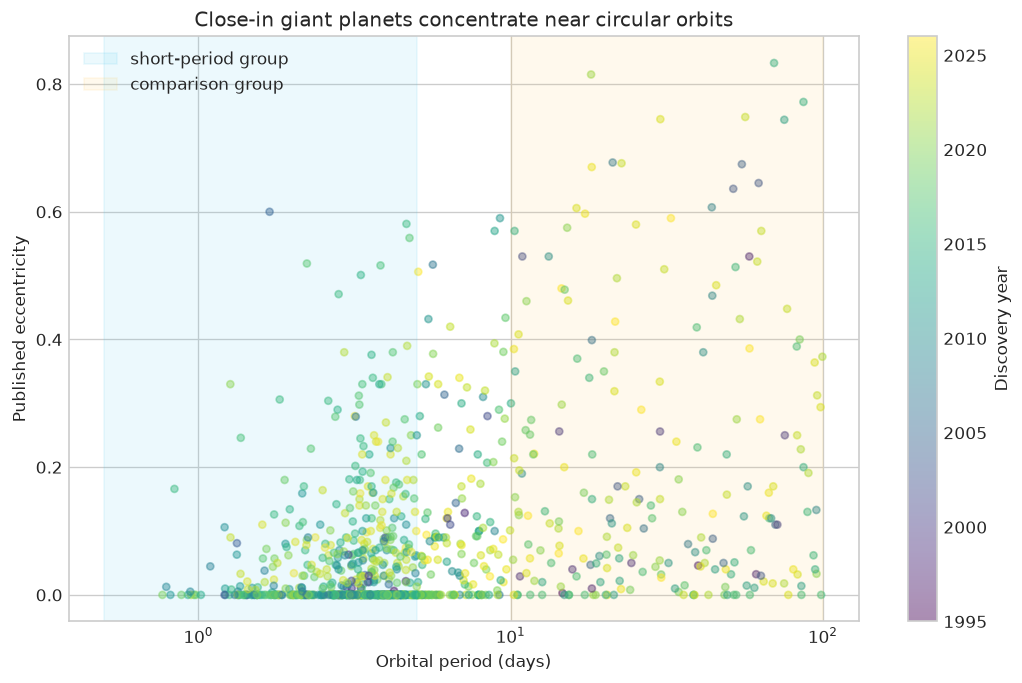

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.8))
sc = ax.scatter(giants.pl_orbper, giants.pl_orbeccen, s=18, alpha=.45,
                c=giants.disc_year, cmap="viridis", rasterized=True)
ax.axvspan(.5, 5, color=COLORS["blue"], alpha=.10, label="short-period group")
ax.axvspan(10, 100, color=COLORS["gold"], alpha=.10, label="comparison group")
ax.set_xscale("log")
ax.set(xlabel="Orbital period (days)", ylabel="Published eccentricity",
       title="Close-in giant planets concentrate near circular orbits")
fig.colorbar(sc, ax=ax, label="Discovery year")
ax.legend()
fig.tight_layout()
fig.savefig("giant_eccentricity_period.png", dpi=180)
plt.show()

## Eccentric fraction with Wilson intervals

Because an exact fitted zero and a small measured value do not have identical
meaning, we also use a coarse, interpretable threshold: the fraction with
$e>0.1$. Wilson intervals quantify the finite sample uncertainty.

In [5]:
from statsmodels.stats.proportion import proportion_confint

groups = {"P < 5 d": short, "10 ≤ P < 100 d": long}
fraction_rows = []
for label, values in groups.items():
    k = int(np.sum(values > .1))
    lo, hi = proportion_confint(k, len(values), alpha=.05, method="wilson")
    fraction_rows.append([label, len(values), k/len(values), lo, hi])
ecc_fraction = pd.DataFrame(fraction_rows, columns=["group", "n", "fraction_e_gt_0p1", "ci95_low", "ci95_high"])
ecc_fraction.to_csv("eccentric_fraction.csv", index=False)
ecc_fraction.round(3)

            group    n  fraction_e_gt_0p1  ci95_low  ci95_high
0         P < 5 d  584              0.173     0.144      0.206
1  10 ≤ P < 100 d  215              0.553     0.487      0.618

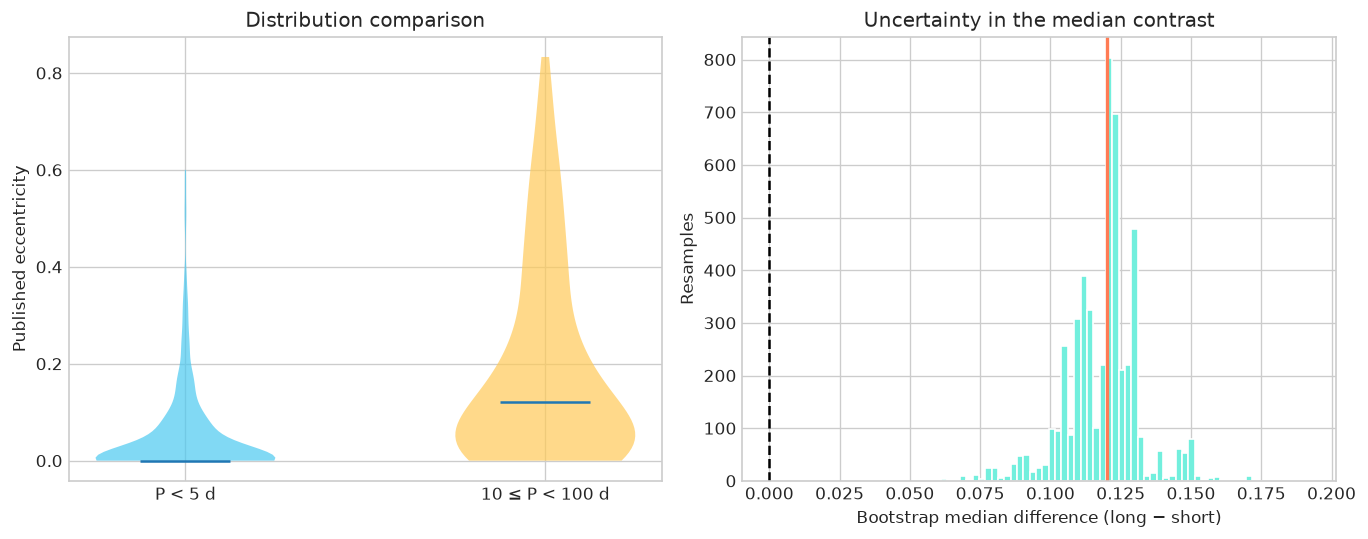

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
parts = axes[0].violinplot([short, long], positions=[0, 1],
                           showmedians=True, showextrema=False)
for body, color in zip(parts["bodies"], [COLORS["blue"], COLORS["gold"]]):
    body.set_facecolor(color); body.set_alpha(.7)
axes[0].set_xticks([0, 1], list(groups))
axes[0].set(ylabel="Published eccentricity", title="Distribution comparison")
axes[1].hist(boot_delta, bins=60, color=COLORS["cyan"], edgecolor="white")
axes[1].axvline(0, color="black", ls="--")
axes[1].axvline(observed_delta, color=COLORS["orange"], lw=2)
axes[1].set(xlabel="Bootstrap median difference (long − short)",
            ylabel="Resamples", title="Uncertainty in the median contrast")
fig.tight_layout()
fig.savefig("tidal_circularisation_test.png", dpi=180)
plt.show()

## Sensitivity check

We repeat the median comparison for several short-period boundaries. A physical
trend should not depend on one exact cut. This is still descriptive: stellar
age, mass, radius, multiplicity, discovery method, and eccentricity reporting
all vary across the archive sample.

In [7]:
checks = []
for boundary in [3, 4, 5, 6, 8]:
    a = giants[giants.pl_orbper < boundary].pl_orbeccen
    checks.append([boundary, len(a), a.median(), np.mean(a > .1)])
sensitivity = pd.DataFrame(checks, columns=["short_boundary_days", "n", "median_e", "fraction_e_gt_0p1"])
sensitivity.round(3)

   short_boundary_days    n  median_e  fraction_e_gt_0p1
0                    3  236     0.000              0.114
1                    4  449     0.000              0.160
2                    5  584     0.000              0.173
3                    6  642     0.000              0.179
4                    8  692     0.008              0.192

## Interpretation

A positive long-minus-short median difference and a much smaller $e>0.1$
fraction at short periods are consistent with tidal circularisation. They do
not show that tides alone produced every circular orbit, nor do they constrain
the tidal dissipation parameter without system ages and a hierarchical model.
Eccentricity measurements near zero are especially vulnerable to positive bias
and to catalogues mixing fixed and freely fitted values.

In [8]:
short_frac = float(ecc_fraction.loc[ecc_fraction.group == "P < 5 d", "fraction_e_gt_0p1"].iloc[0])
long_frac = float(ecc_fraction.loc[ecc_fraction.group == "10 ≤ P < 100 d", "fraction_e_gt_0p1"].iloc[0])
result = {
    "id": "2026-07-31-hot-jupiter-tidal-circularisation",
    "title": "Hot-Jupiter tidal circularisation",
    "archive": "NASA Exoplanet Archive",
    "date": "2026-07-31",
    "question": "Are short-period giant planets more circular than longer-period giants?",
    "sample_size": int(len(giants)),
    "results": [
        f"median e={np.median(short):.3f} below 5 d versus {np.median(long):.3f} at 10–100 d",
        f"median contrast {observed_delta:.3f} (bootstrap 95%: {delta_ci[0]:.3f}–{delta_ci[1]:.3f})",
        f"e>0.1 fractions {100*short_frac:.1f}% versus {100*long_frac:.1f}%"
    ],
    "validation": "The direction of the period–eccentricity contrast matches the standard tidal-circularisation expectation.",
    "notebook": "exoplanet-archive/2026-07-31-hot-jupiter-tidal-circularisation/notebook.ipynb",
    "hero": "exoplanet-archive/2026-07-31-hot-jupiter-tidal-circularisation/giant_eccentricity_period.png",
    "tags": ["exoplanets", "dynamics", "tides", "hot Jupiters"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print("\n".join("• " + x for x in result["results"]))

• median e=0.000 below 5 d versus 0.120 at 10–100 d
• median contrast 0.120 (bootstrap 95%: 0.088–0.149)
• e>0.1 fractions 17.3% versus 55.3%


## References and data acknowledgement


- NASA Exoplanet Archive `pscomppars` table:
  https://exoplanetarchive.ipac.caltech.edu/
- Winn et al. (2010), *Hot Stars with Hot Jupiters Have High Obliquities*,
  discussion of tidal timescales: https://doi.org/10.1088/2041-8205/718/2/L145
- Dawson & Johnson (2018), *Origins of Hot Jupiters*:
  https://doi.org/10.1146/annurev-astro-081817-051853
- Archive acknowledgement: https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html


The numerical results above are conditional on the documented cuts. Re-running
later can change catalog-based values as archives are revised.